<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana1/Semana1Dia_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# =====================================================================
# ETAPA 1: Carregamento dos Dados Tabulares
# =====================================================================
print("Carregando o dataset tabular (Palmer Penguins)...")
# Usando o repositório público para carregar o CSV diretamente no Pandas
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
df = pd.read_csv(url)

print("\nEspiada nas primeiras linhas (Dados Brutos):")
print(df.head())
print("-" * 50)


Carregando o dataset tabular (Palmer Penguins)...

Espiada nas primeiras linhas (Dados Brutos):
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  
--------------------------------------------------


In [ ]:
# =====================================================================
# ETAPA 2: Tratamento e Pré-Processamento dos Dados
# =====================================================================
print("Iniciando o tratamento dos dados...")

# 1. Tratando Valores Faltantes (Missing Values) nas colunas numéricas
# Vamos preencher os pinguins que estão sem medições usando a mediana da coluna
colunas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

# 2. Tratando Valores Faltantes na coluna categórica (Sexo)
# Se não soubermos o sexo, preenchemos com a moda (o mais comum)
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

# 3. Tratando Variáveis Categóricas (Convertendo texto em números)
# Algoritmos clássicos não entendem palavras como "Torgersen" (Ilha) ou "Male/Female".
# Transformamos tudo em colunas numéricas binárias (0 ou 1) usando o get_dummies.
df = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

print("\nEspiada após o tratamento (Dados Prontos para ML):")
print(df.head())
print("-" * 50)

# Separando em Features (X) e Alvo (y - Espécie do Pinguim)
X = df.drop('species', axis=1)
y = df['species']

# Separando em dados de Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Iniciando o tratamento dos dados...

Espiada após o tratamento (Dados Prontos para ML):
  species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Adelie           39.10           18.7              181.0       3750.0   
1  Adelie           39.50           17.4              186.0       3800.0   
2  Adelie           40.30           18.0              195.0       3250.0   
3  Adelie           44.45           17.3              197.0       4050.0   
4  Adelie           36.70           19.3              193.0       3450.0   

   island_Dream  island_Torgersen  sex_MALE  
0         False              True      True  
1         False              True     False  
2         False              True     False  
3         False              True      True  
4         False              True     False  
--------------------------------------------------


In [ ]:
# =====================================================================
# ETAPA 3: Treinamento dos 3 Modelos
# =====================================================================
print("\nTreinando os modelos...")

# Instanciando os modelos
modelos = {
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Dicionário para guardar as previsões de cada um
previsoes = {}

# Treinando e guardando as previsões em loop
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes[nome] = modelo.predict(X_test)
    print(f"{nome} treinado com sucesso!")

print("-" * 50)


Treinando os modelos...
Árvore de Decisão treinado com sucesso!
Random Forest treinado com sucesso!
Gradient Boosting treinado com sucesso!
--------------------------------------------------



=== AVALIAÇÃO DETALHADA DOS MODELOS ===

MODELO: Árvore de Decisão
Acurácia Geral: 95.19%

Relatório de Classificação:
              precision    recall  f1-score   support

      Adelie       0.98      0.94      0.96        50
   Chinstrap       0.83      0.95      0.88        20
      Gentoo       1.00      0.97      0.99        34

    accuracy                           0.95       104
   macro avg       0.94      0.95      0.94       104
weighted avg       0.96      0.95      0.95       104



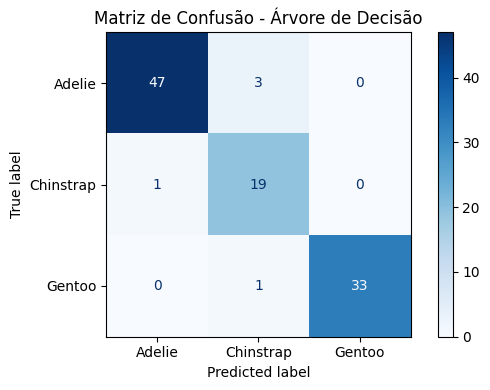


MODELO: Random Forest
Acurácia Geral: 99.04%

Relatório de Classificação:
              precision    recall  f1-score   support

      Adelie       1.00      0.98      0.99        50
   Chinstrap       1.00      1.00      1.00        20
      Gentoo       0.97      1.00      0.99        34

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



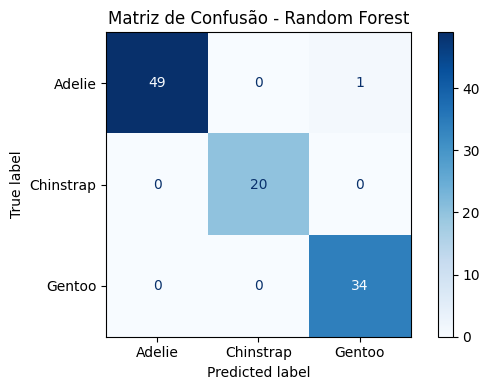


MODELO: Gradient Boosting
Acurácia Geral: 98.08%

Relatório de Classificação:
              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        50
   Chinstrap       1.00      0.95      0.97        20
      Gentoo       0.97      1.00      0.99        34

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



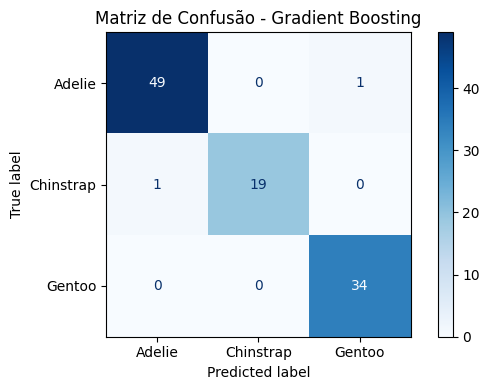

In [ ]:
# =====================================================================
# ETAPA 4: Avaliação Detalhada de TODOS os modelos
# =====================================================================
print("\n=== AVALIAÇÃO DETALHADA DOS MODELOS ===")

for nome, prev in previsoes.items():
    print(f"\n" + "="*40)
    print(f"MODELO: {nome}")
    print("="*40)

    # 1. Acurácia
    acuracia = accuracy_score(y_test, prev)
    print(f"Acurácia Geral: {acuracia * 100:.2f}%\n")

    # 2. Classification Report
    print("Relatório de Classificação:")
    print(classification_report(y_test, prev))

    # 3. Matriz de Confusão Visual
    # Pegamos as classes a partir do próprio modelo treinado
    classes_modelo = modelos[nome].classes_
    cm = confusion_matrix(y_test, prev, labels=classes_modelo)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_modelo)

    # Plotando
    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.tight_layout()
    plt.show() # O plt.show() no loop vai abrir uma janela por vez ou plotar em sequência no Jupyter

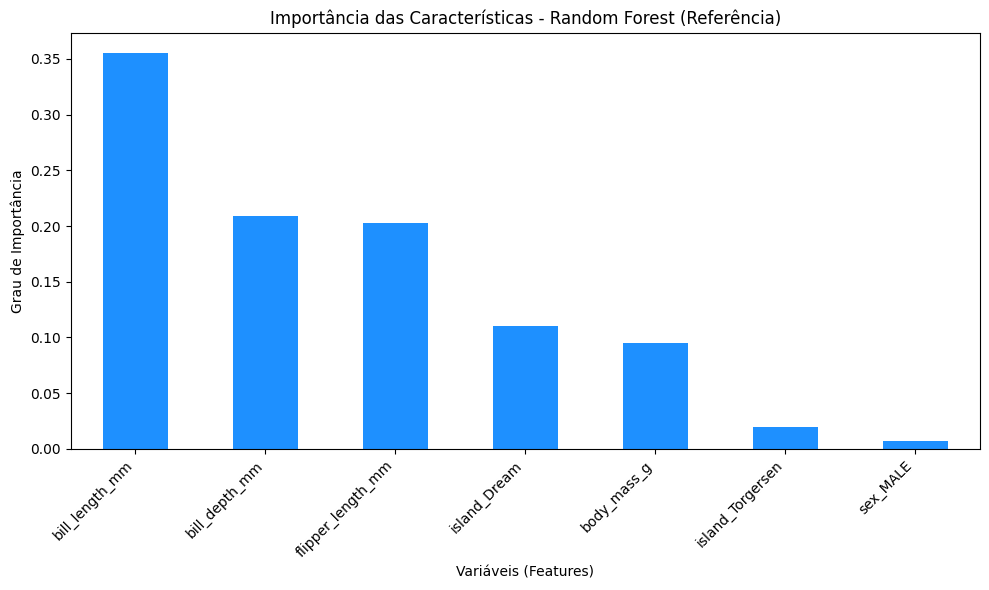

In [ ]:
# =====================================================================
# ETAPA 5: Visualizando a Importância das Características (Feature Importance)
# =====================================================================
# Usaremos o Random Forest como referência para as features
modelo_rf_treinado = modelos["Random Forest"]
importancias = modelo_rf_treinado.feature_importances_
importancias_df = pd.Series(importancias, index=X.columns).sort_values(ascending=False)

# Plotando o gráfico de Importância
plt.figure(figsize=(10, 6))
importancias_df.plot(kind='bar', color='dodgerblue')
plt.title('Importância das Características - Random Forest (Referência)')
plt.ylabel('Grau de Importância')
plt.xlabel('Variáveis (Features)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()